
Processing ariane133
Loading benchmark from: ../benchmark_cache/ariane133.pt, design: ariane133
Number of macros: 132
Number of nets: 452
Ratio x: 33.785714285714285, Ratio y: 33.7171052631579, Sum: 67.50281954887218
Max width, height: 7568.0, 7552.631578947369
Successfully saved graph and coordinates for ariane133.
max, min of coords: 0.8620976805686951, -0.9447465538978577
max, min of cond.x: 0.10808669030666351, 0.056585367769002914


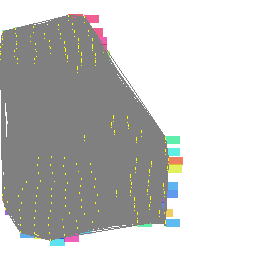

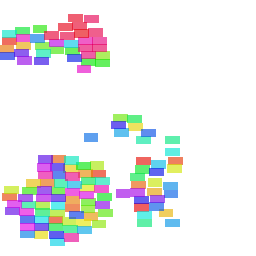

HPWL: 2291.9677002057433
Sample macro_pos (original): [(167673, (3987.0264, 1324.2896, 409.00003, 213.68422))]
Sample macro_pos (grid): [(167673, (116, 37, 15, 9))]

Processing ariane136
Loading benchmark from: ../benchmark_cache/ariane136.pt, design: ariane136
Number of macros: 136
Number of nets: 457
Ratio x: 33.785714285714285, Ratio y: 33.7171052631579, Sum: 67.50281954887218
Max width, height: 7568.0, 7552.631578947369
Successfully saved graph and coordinates for ariane136.
max, min of coords: 0.8980000615119934, -0.945713222026825
max, min of cond.x: 0.10808669030666351, 0.056585367769002914


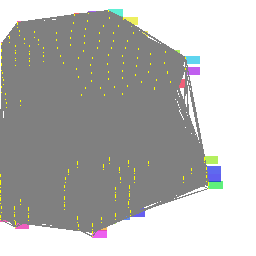

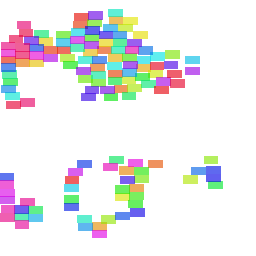

HPWL: 2266.898929586634
Sample macro_pos (original): [(171094, (1925.2632, 2139.2368, 409.00003, 213.68422))]
Sample macro_pos (grid): [(171094, (54, 61, 15, 9))]

Processing bp_be
Loading benchmark from: ../benchmark_cache/bp_be.pt, design: bp_be
Number of macros: 10
Number of nets: 23
Ratio x: 18.558035714285715, Ratio y: 16.184210526315788, Sum: 34.7422462406015
Max width, height: 4157.0, 3625.2631578947367
Successfully saved graph and coordinates for bp_be.
max, min of coords: 0.7822190523147583, -0.787703275680542
max, min of cond.x: 0.3863363265991211, 0.028385857120156288


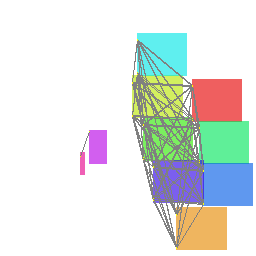

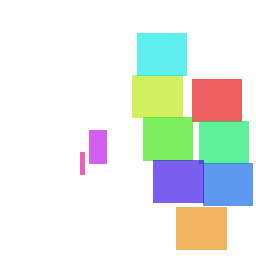

HPWL: 153.32147541455925
Sample macro_pos (original): [(51383, (3120.816, 1907.8685, 803.00006, 596.8421))]
Sample macro_pos (grid): [(51383, (166, 115, 46, 39))]

Processing bp_fe
Loading benchmark from: ../benchmark_cache/bp_fe.pt, design: bp_fe
Number of macros: 11
Number of nets: 15
Ratio x: 18.558035714285715, Ratio y: 13.848684210526315, Sum: 32.40671992481203
Max width, height: 4157.0, 3102.1052631578946
Successfully saved graph and coordinates for bp_fe.
max, min of coords: 0.7933353781700134, -0.8535629510879517
max, min of cond.x: 0.3863363265991211, 0.026942508295178413


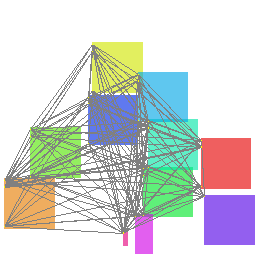

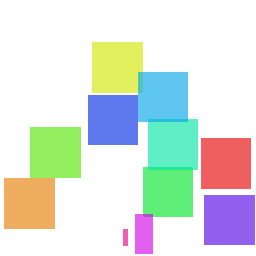

HPWL: 120.38166618347168
Sample macro_pos (original): [(33189, (3270.6055, 823.9737, 803.00006, 596.8421))]
Sample macro_pos (grid): [(33188, (176, 7, 48, 48))]

Processing bp
Loading benchmark from: ../benchmark_cache/bp.pt, design: bp
Number of macros: 24
Number of nets: 45
Ratio x: 31.477678571428573, Ratio y: 30.29605263157895, Sum: 61.77373120300752
Max width, height: 7051.0, 6786.315789473684
Successfully saved graph and coordinates for bp.
max, min of coords: 0.8637745976448059, -0.9010779857635498
max, min of cond.x: 0.22776912152767181, 0.015884272754192352


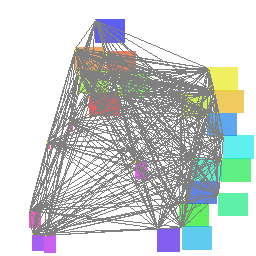

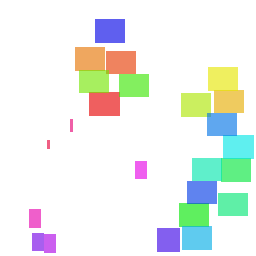

HPWL: 192.5824253913015
Sample macro_pos (original): [(306798, (2477.8423, 3729.3423, 803.00006, 596.8421))]
Sample macro_pos (grid): [(306795, (26, 2, 12, 18))]

Processing swerv_wrapper
Loading benchmark from: ../benchmark_cache/swerv_wrapper.pt, design: swerv_wrapper
Number of macros: 28
Number of nets: 213
Ratio x: 25.84375, Ratio y: 23.486842105263158, Sum: 49.33059210526316
Max width, height: 5789.0, 5261.0526315789475
Successfully saved graph and coordinates for swerv_wrapper.
max, min of coords: 0.871334969997406, -0.9060924053192139
max, min of cond.x: 0.4397759437561035, 0.028675073757767677


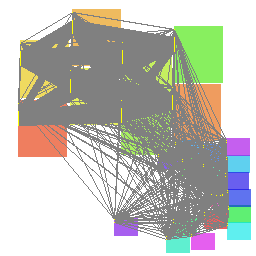

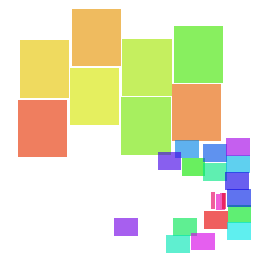

HPWL: 775.2499425522983
Sample macro_pos (original): [(98087, (4632.6055, 563.1316, 518.0, 346.3158))]
Sample macro_pos (grid): [(98079, (59, 112, 45, 54))]

Summary of all benchmarks:
ariane133: HPWL=2291.9677002057433
ariane136: HPWL=2266.898929586634
bp_be: HPWL=153.32147541455925
bp_fe: HPWL=120.38166618347168
bp: HPWL=192.5824253913015
swerv_wrapper: HPWL=775.2499425522983


In [3]:
import torch
import numpy as np
import os
import sys
sys.path.append('../')
sys.path.append('../flow_matching')
import numpy as np
import torch
from torch_geometric.data import Data
from itertools import combinations
from collections import defaultdict
import pickle
from PIL import Image
from  flow_matching.utils import visualize_placement, hpwl_fast, hpwl 


# Define Args class as in the original
class Args:
    def __init__(self, **kwargs):
        for key, value in kwargs.items():
            setattr(self, key, value)

# Extended PlaceDBInstanceOpenROAD with macro_pos generation
class PlaceDBInstanceOpenROAD:
    def __init__(self, args, design_name, path) -> None:
        self.args = args
        self.design_name = design_name
        print(f"Loading benchmark from: {path}, design: {design_name}")
        benchmark_info = torch.load(path, weights_only=False)
        self.benchmark_info = benchmark_info
        self.canvas_size_x = benchmark_info["ratio_x"] * args.grid  # Assuming grid=224 as in ICCAD
        self.canvas_size_y = benchmark_info["ratio_y"] * args.grid
        self.grid_size_x = self.canvas_size_x / args.n_grid if hasattr(args, 'n_grid') else benchmark_info["ratio_x"]
        self.grid_size_y = self.canvas_size_y / args.n_grid if hasattr(args, 'n_grid') else benchmark_info["ratio_y"]

        self.node_info = benchmark_info["node_info"]
        self.net_info = benchmark_info["net_info"]
        self.node_to_net_dict = benchmark_info["node_to_net_dict"]  # Note: renamed to match ICCAD convention
        # print macro nums, net nums
        print(f"Number of macros: {len(benchmark_info['node_id_to_name'])}")
        print(f"Number of nets: {len(benchmark_info['net_info'])}")
        self.macro_names = benchmark_info["node_id_to_name"]
        self.place_order = benchmark_info["node_id_to_name"]
        self.macro_name2index_map = {name: i for i, name in enumerate(self.macro_names)}

        self.macro_size_x = []
        self.macro_size_y = []
        for macro in self.macro_names:
            self.macro_size_x.append(self.node_info[macro]["x"])
            self.macro_size_y.append(self.node_info[macro]["y"])
        self.macro_size_x = np.array(self.macro_size_x)
        self.macro_size_y = np.array(self.macro_size_y)

        self.macro_size_grid_x = np.ceil(np.maximum(1, self.macro_size_x / self.grid_size_x)).astype(np.int32)
        self.macro_size_grid_y = np.ceil(np.maximum(1, self.macro_size_y / self.grid_size_y)).astype(np.int32)
        
        # Additional attributes from benchmark_info
        self.macro_clusters = benchmark_info["macro_clusters"]
        self.dataflow_mat = benchmark_info["dataflow_mat"]
        self.id2index = benchmark_info["id2index"]
        self.port_pos = benchmark_info["port_pos"]
        #for port in self.port_pos:
        #    print(f"Port {port} position: {self.port_pos[port]}")
        self.pin_blocking_rectangles = benchmark_info["pin_blocking_rectangles"]
        

        self.ratio_x = self.canvas_size_x / args.grid
        self.ratio_y = self.canvas_size_y / args.grid
        self.ratio_sum = self.ratio_x + self.ratio_y
        print(f"Ratio x: {self.ratio_x}, Ratio y: {self.ratio_y}, Sum: {self.ratio_sum}")
        # Build PyG data (similar to ICCAD's _build_pyg_data)
        self.x, self.cond = self._build_pyg_data()

    def _build_pyg_data(self):
        V = len(self.macro_names)
        node_name_to_id = {name: i for i, name in enumerate(self.macro_names)}

        # Normalize sizes to [0, 2] corresponding to chip normalized to [-1, 1]
        # Using 'x' and 'y' from node_info as sizes (similar to ICCAD)
        sizes = []
        max_width = self.canvas_size_x
        max_height = self.canvas_size_y
        for name in self.macro_names:
            sx = 2 * self.node_info[name]['x'] / max_width
            sy = 2 * self.node_info[name]['y'] / max_height
            sizes.append([sx, sy])
        cond_x = torch.tensor(sizes, dtype=torch.float32)

        # is_ports all 0 (assuming no ports as in ICCAD)
        is_ports = torch.zeros((V, 1), dtype=torch.float32)

        # Normalize initial positions (centers) to [-1, 1]
        # Using 'raw_x' and 'raw_y' as initial positions, add size/2 for center
        positions = []
        for name in self.macro_names:
            center_x = self.node_info[name].get("raw_x", 0) + self.node_info[name]['x'] / 2
            center_y = self.node_info[name].get("raw_y", 0) + self.node_info[name]['y'] / 2
            norm_x = 2 * center_x / max_width - 1
            norm_y = 2 * center_y / max_height - 1
            positions.append([norm_x, norm_y])
        x = torch.tensor(positions, dtype=torch.float32)

        # Build edges and attrs using net_info directly (similar to ICCAD)
        edge_list = []
        attr_list = []
        for net_name in self.net_info:
            macro_to_off = {}
            for macro in self.net_info[net_name]["nodes"]:
                off_x = self.net_info[net_name]["nodes"][macro].get("x_offset", 0)
                off_y = self.net_info[net_name]["nodes"][macro].get("y_offset", 0)
                norm_off_x = 2 * off_x / max_width
                norm_off_y = 2 * off_y / max_height
                macro_to_off[macro] = (norm_off_x, norm_off_y)

            connected_macros = list(macro_to_off.keys())
            if len(connected_macros) < 2:
                continue

            for a, b in combinations(connected_macros, 2):
                off_a = macro_to_off[a]
                off_b = macro_to_off[b]
                i = node_name_to_id[a]
                j = node_name_to_id[b]
                edge_list.append([i, j])
                attr_list.append([off_a[0], off_a[1], off_b[0], off_b[1]])
                edge_list.append([j, i])
                attr_list.append([off_b[0], off_b[1], off_a[0], off_a[1]])

        if edge_list:
            edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
            edge_attr = torch.tensor(attr_list, dtype=torch.float32)
        else:
            print("Warning: no edges in the graph.")
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_attr = torch.empty((0, 4), dtype=torch.float32)

        cond = Data(x=cond_x, edge_index=edge_index, edge_attr=edge_attr, is_ports=is_ports)
        chip_size = np.array([0.0, 0.0, 2.0, 2.0])  # normalized to [-1, 1]
        cond.chip_size = chip_size
        cond.benchmark_name = self.design_name  # Set benchmark_name
        return x, cond

    def get_macro_pos(self, in_grid_space=False):
        """
        Generate macro_pos dict.
        - If in_grid_space=True, use prototype grid positions from 'macro_pos_prototype' (e.g., (x, y, w, h) in grid).
        - If in_grid_space=False, use original space positions: raw_x, raw_y, x (size), y (size).
        """
        macro_pos = {}
        if in_grid_space:
            # Use macro_pos_prototype if available, assuming it's in grid space
            if "macro_pos_prototype" in self.benchmark_info:
                macro_pos = self.benchmark_info["macro_pos_prototype"]
            else:
                # Fallback: compute grid positions from raw_x/y and sizes
                for name in self.macro_names:
                    grid_x = int(self.node_info[name].get("raw_x", 0) / self.grid_size_x)
                    grid_y = int(self.node_info[name].get("raw_y", 0) / self.grid_size_y)
                    grid_w = self.macro_size_grid_x[self.macro_name2index_map[name]]
                    grid_h = self.macro_size_grid_y[self.macro_name2index_map[name]]
                    macro_pos[name] = (grid_x, grid_y, grid_w, grid_h)
        else:
            # Original space: (raw_x, raw_y, size_x, size_y)
            for name in self.macro_names:
                orig_x = self.node_info[name].get("raw_x", 0)
                orig_y = self.node_info[name].get("raw_y", 0)
                size_x = self.node_info[name]['x']
                size_y = self.node_info[name]['y']
                macro_pos[name] = (orig_x, orig_y, size_x, size_y)
        return macro_pos

# Main script to process benchmarks, similar to ICCAD2015
args = Args(BENCHMARK_DIR="../benchmark_cache",  # Adjust path as needed
            grid=224,
            n_grid=224) 

benchmark_list = ["ariane133", "ariane136", "bp_be", "bp_fe", "bp", "swerv_wrapper"]

output_dir = "../datasets/graph/openroad-s0"  # s for self-converted
os.makedirs(output_dir, exist_ok=True)
results = {}
problem_instances = {}

for idx, benchmark_name in enumerate(benchmark_list):
    print(f"\n{'='*50}")
    print(f"Processing {benchmark_name}")
    print(f"{'='*50}")
    
    # Assume paths to .pt files, e.g., f"{args.BENCHMARK_DIR}/{benchmark_name}.pt"
    path = os.path.join(args.BENCHMARK_DIR, f"{benchmark_name}.pt")  # Adjust if different
    
    # Create problem instance using the extended class
    problem_instance = PlaceDBInstanceOpenROAD(args, benchmark_name, path)
    print(f"Max width, height: {problem_instance.canvas_size_x}, {problem_instance.canvas_size_y}")
    problem_instances[benchmark_name] = problem_instance

    coords, cond = problem_instance.x, problem_instance.cond
    cond.benchmark_name = benchmark_name  # Already set, but ensure
    cond_path = os.path.join(output_dir, f"graph{idx}.pickle")
    x_path = os.path.join(output_dir, f"output{idx}.pickle")

    with open(cond_path, 'wb') as f:
        pickle.dump(cond, f)
    with open(x_path, 'wb') as f:
        pickle.dump(coords, f)
    print(f"Successfully saved graph and coordinates for {benchmark_name}.")

    print(f"max, min of coords: {coords.max()}, {coords.min()}")
    print(f"max, min of cond.x: {cond.x.max()}, {cond.x.min()}")
    
    # Visualize (assuming visualize_placement exists)
    img = visualize_placement(coords, cond, True, True)
    Image.fromarray(img).show()
    img_without_net = visualize_placement(coords, cond, False, False)
    Image.fromarray(img_without_net).show()

    # Compute metrics
    hpwl_result = hpwl(coords, cond)
    
    # Save results
    results[benchmark_name] = {
        'hpwl': hpwl_result,
    }
    
    print(f"HPWL: {hpwl_result}")

    # Example: Get macro_pos in both spaces
    macro_pos_original = problem_instance.get_macro_pos(in_grid_space=False)
    macro_pos_grid = problem_instance.get_macro_pos(in_grid_space=True)
    print(f"Sample macro_pos (original): {list(macro_pos_original.items())[:1]}")
    print(f"Sample macro_pos (grid): {list(macro_pos_grid.items())[:1]}")

# Print summary
print(f"\n{'='*50}")
print("Summary of all benchmarks:")
print(f"{'='*50}")
for benchmark_name, metrics in results.items():
    print(f"{benchmark_name}: HPWL={metrics['hpwl']}")

In [4]:
config_file = """
# Copy this into the benchmark directory
train_samples: 0
val_samples: 6 # change this to the number of circuits in benchmark (18 for ibm, 8 for ispd)
scale: 1
chip_width: 2.0
chip_height: 2.0
preprocessed: true
"""
with open(os.path.join(output_dir, "config.yaml"), 'w') as f:
    f.write(config_file)